In [1]:
# This cell imports libraries for loading the dataset, preprocessing descriptions, TF-IDF, SVD, plotting, and saving files.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import html
import contractions
import nltk
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# This cell loads the full 10k TTRPG + BGG dataset.

df = pd.read_csv("../marc/ttrpg_bgg_full_dataset_10k.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (10000, 6)
Columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Category', 'Mechanics']


,Name,Description,Average Score,Number of Reviews,Category,Mechanics
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors']
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El..."
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors']
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors']
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El..."


In [4]:
# This cell cleans the rows needed for description-based SVD.
# Only rows with a valid Description are needed for TF-IDF and SVD.

df = df.dropna(subset=["Description"]).copy()

df["Description"] = df["Description"].astype(str)

df = df[
    df["Description"].str.strip() != ""
].copy()

# Convert score/review columns to numeric if they exist.
if "Average Score" in df.columns:
    df["Average Score"] = pd.to_numeric(df["Average Score"], errors="coerce")

if "Number of Reviews" in df.columns:
    df["Number of Reviews"] = pd.to_numeric(df["Number of Reviews"], errors="coerce")

print("Cleaned dataset shape:", df.shape)

df.head()

Cleaned dataset shape: (10000, 6)


,Name,Description,Average Score,Number of Reviews,Category,Mechanics
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors']
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El..."
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors']
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors']
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El..."


In [5]:
# This cell defines the text preprocessing function for descriptions.
# It fixes HTML symbols, expands contractions, tokenizes, removes stopwords, keeps alphabetic words, and lemmatizes.

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_nltk_alpha_only(text):
    text = html.unescape(str(text))
    text = contractions.fix(text)

    tokens = word_tokenize(text.lower())

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [6]:
# This cell preprocesses only the Description column.
# This is the only column that will go into TF-IDF and SVD.

descs = df["Description"].astype(str).tolist()

processed_descriptions = [
    preprocess_nltk_alpha_only(doc)
    for doc in descs
]

print("Number of processed descriptions:", len(processed_descriptions))

processed_descriptions[:3]

Number of processed descriptions: 10000


['pressman take classic game put exciting console plus even player play time turn wheel pick rock paper scissors flip reveal shield score point player beat special game hub included play',
 'show good loser show real loser oneupmanship satirical board game player struggle money power ego winner first player earn mean possible playing stock market building skyscraper gambling collecting trophy',
 'pressman take classic game put exciting console plus even player play time turn wheel pick rock paper scissors flip reveal shield score point player beat special game hub included play']

In [7]:
# This cell converts only the processed descriptions into a TF-IDF matrix.
# This TF-IDF matrix is the actual input to SVD.

tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

X_tfidf = tfidf_vectorizer.fit_transform(processed_descriptions)

print("TF-IDF shape from Description only:", X_tfidf.shape)

TF-IDF shape from Description only: (10000, 10274)


In [8]:
# This cell fits TruncatedSVD on the TF-IDF matrix made from descriptions only.
# SVD is not applied to the full dataset, only to the Description-based TF-IDF matrix.

max_components = min(
    5000,
    X_tfidf.shape[0] - 1,
    X_tfidf.shape[1] - 1
)

svd_model = TruncatedSVD(
    n_components=max_components,
    random_state=42
)

svd_model.fit(X_tfidf)

print("SVD fitted with components:", max_components)

SVD fitted with components: 5000


In [9]:
# This cell finds how many singular values are needed to reach 90% explained variance.

energy = svd_model.singular_values_**2
energy_ratio = energy / energy.sum()
energy_ratio_cumsum = energy_ratio.cumsum()

n_svs_90 = None

for i in range(len(energy_ratio_cumsum)):
    if energy_ratio_cumsum[i] >= 0.90:
        n_svs_90 = i + 1
        print(f"Explained variance at {n_svs_90} SVs: {energy_ratio_cumsum[i]:.2f}")
        break

if n_svs_90 is None:
    print(f"Did not reach 0.90. Max explained variance: {energy_ratio_cumsum[-1]:.2f}")

Explained variance at 1804 SVs: 0.90


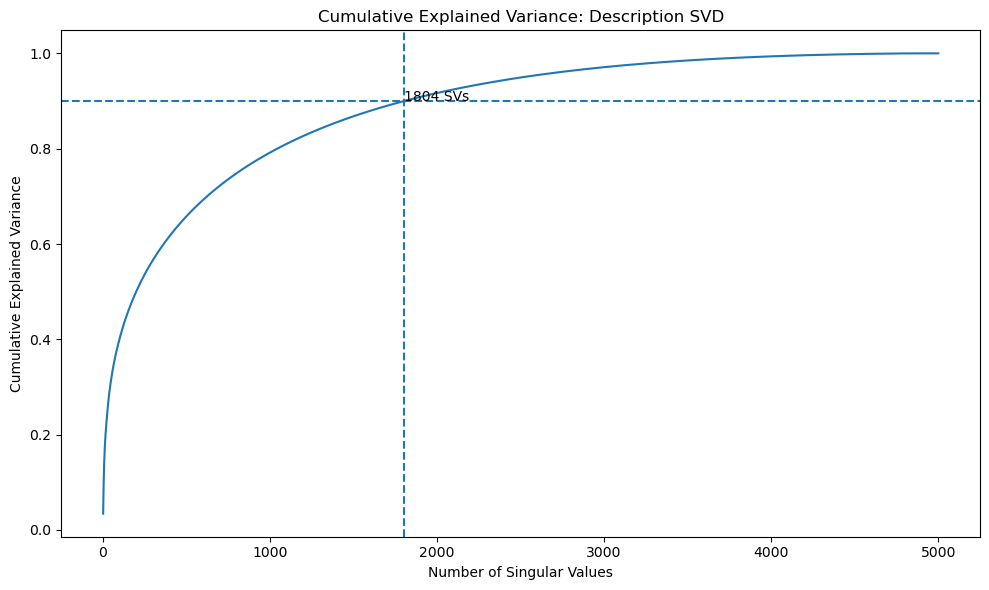

In [10]:
# This cell plots cumulative explained variance and marks the 90% threshold.

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(energy_ratio_cumsum) + 1),
    energy_ratio_cumsum
)

plt.axhline(0.90, linestyle="--")

if n_svs_90 is not None:
    plt.axvline(n_svs_90, linestyle="--")
    plt.text(n_svs_90, 0.90, f"{n_svs_90} SVs")

plt.title("Cumulative Explained Variance: Description SVD")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [11]:
# This cell transforms the description TF-IDF matrix into SVD vectors.
# Then it attaches those description-based SVD vectors back to the original dataset.

final_n_svs = n_svs_90

X_svd_final = svd_model.transform(X_tfidf)[:, :final_n_svs]

svd_description_table = pd.DataFrame(
    X_svd_final,
    columns=[f"SV_{i+1}" for i in range(final_n_svs)]
)

description_svd_table = pd.concat(
    [
        df.reset_index(drop=True),
        svd_description_table.reset_index(drop=True)
    ],
    axis=1
)

description_svd_table.to_csv("ttrpg_bgg_description_svd_table.csv", index=False)

print("Final description-SVD table shape:", description_svd_table.shape)

description_svd_table.head()

Final description-SVD table shape: (10000, 1810)


,Name,Description,Average Score,Number of Reviews,Category,Mechanics,SV_1,SV_2,SV_3,SV_4,...,SV_1795,SV_1796,SV_1797,SV_1798,SV_1799,SV_1800,SV_1801,SV_1802,SV_1803,SV_1804
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors'],0.301526,-0.209281,0.343165,0.176303,...,-0.000128,0.000033,-0.000011,-0.000027,-0.000215,-0.000015,-0.000059,4.159818e-05,0.000269,-0.000147
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",0.206572,-0.123297,0.203228,-0.626003,...,-0.000094,-0.000018,-0.000003,-0.000195,-0.000024,0.000157,-0.000124,2.293697e-07,-0.000043,0.000027
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors'],0.301526,-0.209281,0.343165,0.176303,...,-0.000128,0.000033,-0.000011,-0.000027,-0.000215,-0.000015,-0.000059,4.159818e-05,0.000269,-0.000147
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,['Action / Dexterity'],['Rock-Paper-Scissors'],0.301526,-0.209281,0.343165,0.176303,...,-0.000128,0.000033,-0.000011,-0.000027,-0.000215,-0.000015,-0.000059,4.159818e-05,0.000269,-0.000147
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,"['Economic', 'Negotiation']","['Auction/Bidding', 'Dice Rolling', 'Player El...",0.206572,-0.123297,0.203228,-0.626003,...,-0.000094,-0.000018,-0.000003,-0.000195,-0.000024,0.000157,-0.000124,2.293697e-07,-0.000043,0.000027


In [12]:
# This cell checks the output CSV file size before pushing to GitHub.

file_name = "ttrpg_bgg_description_svd_table.csv"

if os.path.exists(file_name):
    file_size_mb = os.path.getsize(file_name) / (1024 * 1024)
    print(f"{file_name}: {file_size_mb:.2f} MB")
else:
    print(f"{file_name} not found.")

ttrpg_bgg_description_svd_table.csv: 385.48 MB


## Description-Based SVD Result

This notebook applies TF-IDF and TruncatedSVD only to the `Description` column of `ttrpg_bgg_full_dataset_10k.csv`. The other columns, such as `Name`, `Average Score`, `Number of Reviews`, category columns, and mechanics columns, are not used as input to SVD. They are only kept in the final exported table beside the description-based SVD vectors.

The final number of retained singular values is selected based on the point where cumulative explained variance reaches 0.90.